In [2]:
"""
example code for state estimation via Kalman Filter in case of free vibration
@author: LC
"""

import numpy as np
import matplotlib.pyplot as plt

def kalman_filter(z_prev, P_prev,A,H,Q,R,d): 
    # Kalman Filter function
    # without considering any input load
    
    #prediction step
    z_pred = A@z_prev
    P_pred = A@P_prev@A.T + Q
    
    #Kalman Gain
    Kgain = P_pred @ H.T @ np.linalg.inv(H @ P_pred @ H.T + R)
    
    # estimation
    z_est = z_pred + Kgain @ (d - H@ z_pred)
    P_est = P_pred - Kgain @ H @ P_pred
    
    return z_est, P_est

In [3]:

# =============================================================================
# Define state space matrices
# =============================================================================

# state transition matrix (computed elsewhere)
A = np.array([[ 9.87610634e-01,  7.42403599e-03,  9.88586175e-03, 5.39785161e-05],
              [ 7.42403599e-03,  9.92559992e-01,  5.39785161e-05, 9.92184743e-03],
              [-2.46336866e+00,  1.47478248e+00,  9.73143171e-01,1.32051843e-02],
              [ 1.47478248e+00, -1.48018034e+00,  1.32051843e-02,9.81946628e-01]])

#output matrix (computed elsewhere)
H = np.array([[ 150. , -150.  , 0.59064779, -1.07290968]])

#measurements (computed elsewhere)
d = np.loadtxt("measurement_KF_acc2.out").reshape(1,-1)

#measurements noise variance (computed elsewhere)
R = np.array([[1.157]]) # noise variance (assumed known)

#number of time steps
N = d.shape[1]

#number of states
n_states = len(A)

#Process noise covariance matrix
Q = 1e-2*np.eye(n_states) ##just something small


In [4]:
# =============================================================================
# Kalman Filter estimation
# =============================================================================
#initialize vector for estimation
z_kf = np.zeros([n_states,N])


## initial state and error covariance
z0 = np.zeros(n_states) + 1

print("initial state: ", z0)
P0 = np.eye(n_states) * 1  # 10 is relatively big compared to magnitude of displacements

#use P as error covariance without saving it.
P = np.copy(P0); #initial error covariance

#KF loop
for k in range(1,N):
    z_kf[:,k],P = kalman_filter(z_kf[:,k-1], P, A, H, Q, R, d[:,k])

initial state:  [1. 1. 1. 1.]


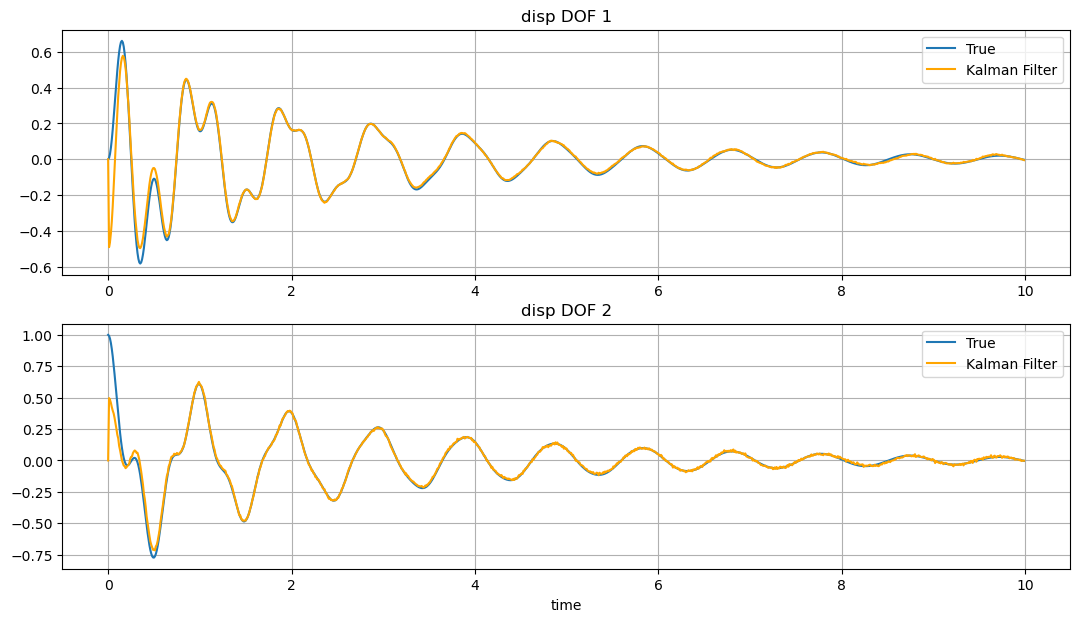

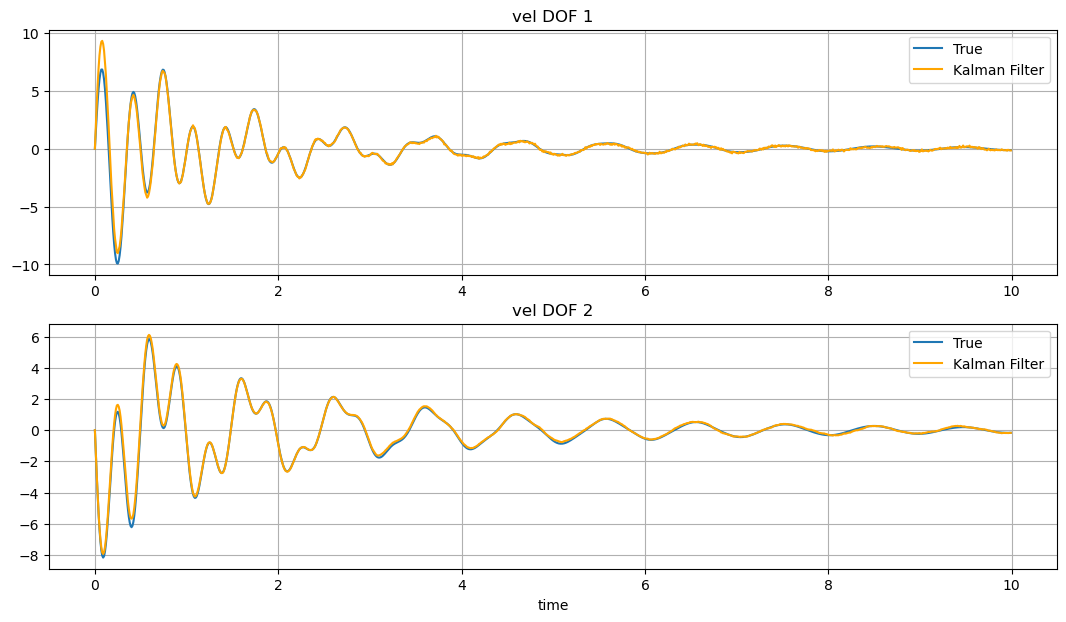

In [5]:
import pickle

# Loading the array with the true responses (displacements and velocities)
with open('z_true.pkl', 'rb') as f:
    z_true = pickle.load(f)

dt = 0.01
t_end = dt*N
time_array = np.arange(N)*dt

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(13,7))
ax1.set_title("disp DOF 1")
ax2.set_title("disp DOF 2")

ax1.plot(time_array,z_true[0,:],label="True")
ax1.plot(time_array,z_kf[0,:],label="Kalman Filter",color="orange")

ax2.plot(time_array,z_true[1,:],label="True")
ax2.plot(time_array,z_kf[1,:],label="Kalman Filter",color="orange")

for ax in (ax1,ax2):
    ax.legend()
    ax.grid()

ax2.set_xlabel("time")
plt.show()

fig, (ax1,ax2) = plt.subplots(2,1,figsize=(13,7))
ax1.set_title("vel DOF 1")
ax2.set_title("vel DOF 2")

ax1.plot(time_array,z_true[2,:],label="True")
ax1.plot(time_array,z_kf[2,:],label="Kalman Filter",color="orange")

ax2.plot(time_array,z_true[3,:],label="True")
ax2.plot(time_array,z_kf[3,:],label="Kalman Filter",color="orange")

for ax in (ax1,ax2):
    ax.legend()
    ax.grid()

ax2.set_xlabel("time")
plt.show()